In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import json

### 1. Load Data

In [2]:
df=pd.read_excel('HSI.xlsx')
df.columns=['Date', 'Open', 'High', 'Low', 'Close', 'Up', 'Down']
df['Date']=pd.to_datetime(df['Date'])
df=df.sort_values('Date').reset_index(drop=True)
df

,Date,Open,High,Low,Close,Up,Down
0,2022-02-23,22088.79,22423.51,21983.10,22154.08,0.28,0.72
1,2022-02-24,23268.03,23376.37,22786.39,22901.56,0.69,0.31
2,2022-02-25,22908.10,23046.86,22718.15,22767.18,0.36,0.64
3,2022-02-28,22818.17,22818.17,22406.12,22713.02,0.61,0.49
4,2022-03-01,22739.84,22937.56,22591.73,22761.71,0.49,0.51
...,...,...,...,...,...,...,...
742,2025-03-06,23987.09,24410.93,23987.09,24369.71,0.60,0.40
743,2025-03-07,24182.02,24669.62,24065.01,24231.30,NaN,NaN
744,2025-03-10,24115.98,24292.80,23632.42,23783.49,0.58,0.42
745,2025-03-11,23274.86,23858.61,23238.36,23782.14,0.41,0.59


In [3]:
df['intraday_return']=(df['Close'] - df['Open'])/df['Open']   
df['vote_spread']=df['Up']-df['Down']
df['bull_day']=(df['intraday_return']>0).astype(int)
df_votes=df.dropna(subset=['Up', 'Down', 'intraday_return']).copy()
df_votes.head(5)

,Date,Open,High,Low,Close,Up,Down,intraday_return,vote_spread,bull_day
0,2022-02-23,22088.79,22423.51,21983.10,22154.08,0.28,0.72,0.002956,-0.44,1
1,2022-02-24,23268.03,23376.37,22786.39,22901.56,0.69,0.31,-0.015750,0.38,0
2,2022-02-25,22908.10,23046.86,22718.15,22767.18,0.36,0.64,-0.006152,-0.28,0
3,2022-02-28,22818.17,22818.17,22406.12,22713.02,0.61,0.49,-0.004608,0.12,0
4,2022-03-01,22739.84,22937.56,22591.73,22761.71,0.49,0.51,0.000962,-0.02,1


In [4]:
print(f"Total trading days: {len(df)}")
print(f"Days with vote data: {len(df_votes)}")
print(f"Data Coverage: {len(df_votes)/len(df) *100: .1f}%")
print(f"Avg Up Vote: {df_votes['Up'].mean() *100: .1f}%")
print(f"Avg Down Vote: {df_votes['Down'].mean() *100: .1f}%")
print(f"Date range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(df_votes[['Up','Down','vote_spread','intraday_return']].describe())

Total trading days: 747
Days with vote data: 552
Data Coverage:  73.9%
Avg Up Vote:  54.1%
Avg Down Vote:  46.0%
Date range: 2022-02-23 to 2025-03-12
               Up        Down  vote_spread  intraday_return
count  552.000000  552.000000   552.000000       552.000000
mean     0.540616    0.459746     0.080870         0.000252
std      0.101998    0.101768     0.203588         0.013055
min      0.240000    0.180000    -0.520000        -0.044924
25%      0.470000    0.390000    -0.060000        -0.008406
50%      0.540000    0.460000     0.080000        -0.000974
75%      0.610000    0.530000     0.220000         0.007702
max      0.820000    0.760000     0.640000         0.059690


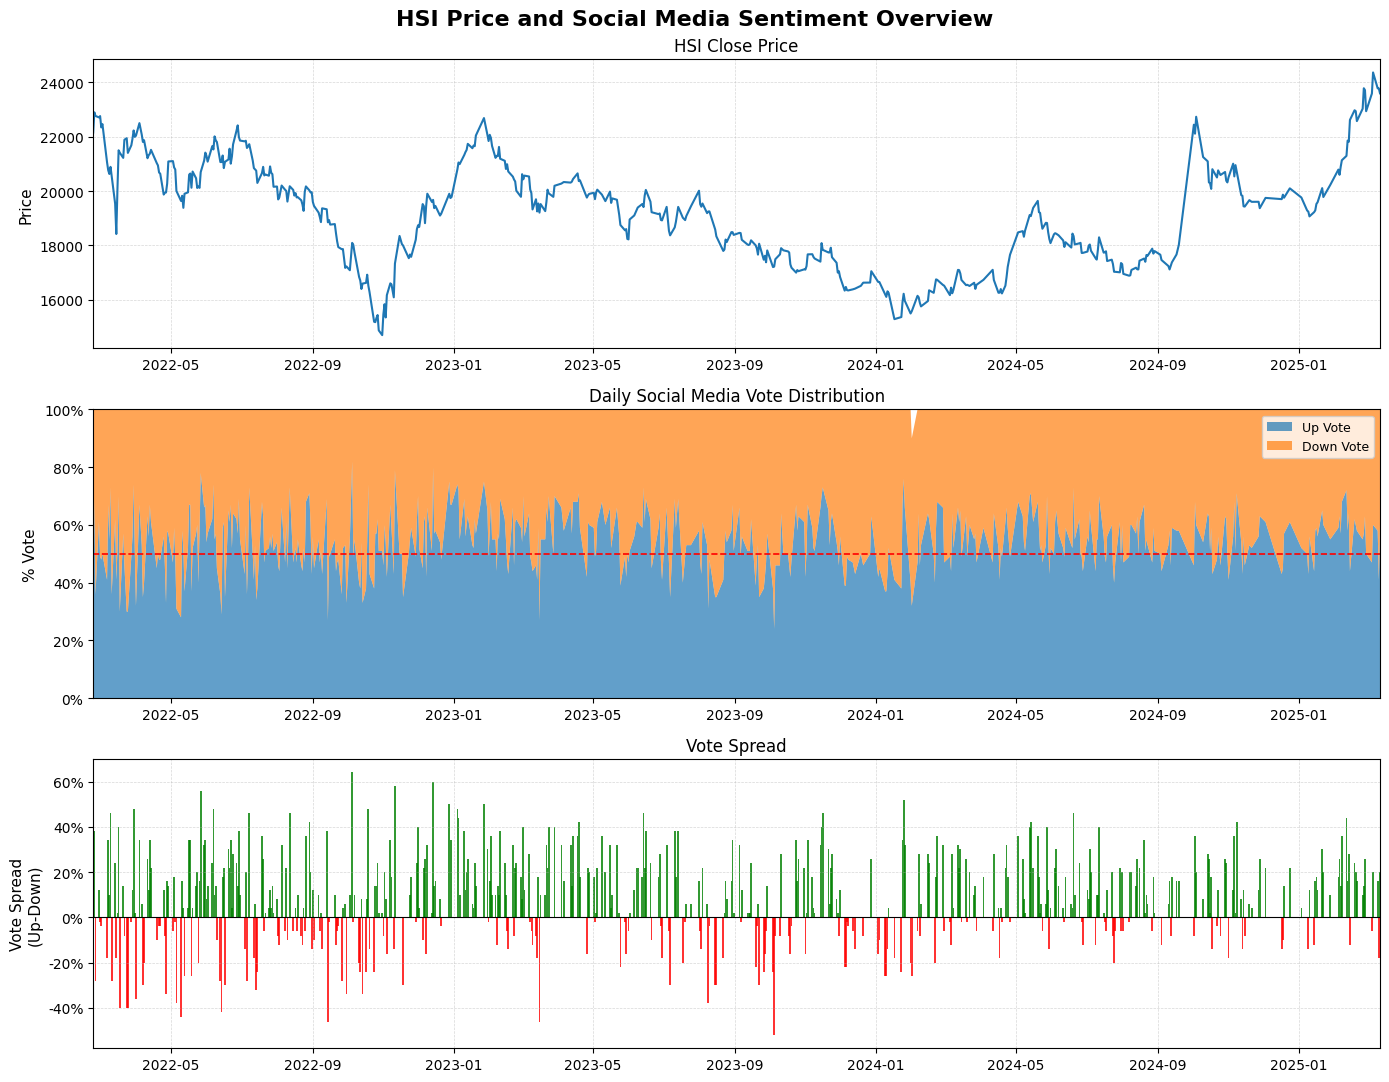

In [5]:
#Fig1: HSI Price + Vote
fig,(ax1,ax2,ax3)=plt.subplots(3,1, figsize=(14,11))
fig.suptitle('HSI Price and Social Media Sentiment Overview',
             fontsize=16, fontweight='bold')
#Price
ax1.plot(df_votes['Date'], df_votes['Close'], lw=1.5, label='HSI Close')
ax1.set_ylabel('Price', fontsize=11)
ax1.set_title('HSI Close Price', fontsize=12)
ax1.grid(True, alpha=0.5, ls='--', linewidth=0.5)

#Up/Down Vote
ax2.stackplot(df_votes['Date'], df_votes['Up'], df_votes['Down'], 
              alpha=0.7, labels=['Up Vote', 'Down Vote'])
ax2.axhline(0.5, lw=1.2, color='r', ls='--')
ax2.set_ylabel('% Vote', fontsize=11)
ax2.set_title('Daily Social Media Vote Distribution', fontsize=12)
ax2.set_ylim(0, 1)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax2.legend(loc='upper right', fontsize=9)

#Vote Spread
colors_bar = ['g' if x > 0 else 'r' for x in df_votes['vote_spread']]
ax3.bar(df_votes['Date'], df_votes['vote_spread'], color=colors_bar, alpha=0.8, width=1.5)
ax3.axhline(0, color='black', lw=0.8)
ax3.set_ylabel('Vote Spread\n(Up-Down)', fontsize=11)
ax3.set_title('Vote Spread', fontsize=12)
ax3.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax3.grid(True, alpha=0.5, ls='--', linewidth=0.5)

for ax in [ax1, ax2, ax3]:
    ax.set_xlim(df_votes['Date'].min(), df_votes['Date'].max())
plt.tight_layout()
fig.savefig('HSI Price Sentiment', dpi=300, bbox_inches='tight')

### 2. Voting Accuracy Analysis

In [6]:
#Check daily accuracy (when major vote up is bullday)
df_votes['major_up']=(df_votes['Up']>0.5).astype(int)
df_votes['right_predict']=(df_votes['major_up']==df_votes['bull_day']).astype(int)

sameday_acc=df_votes['right_predict'].mean()
print(f'Same day Accuracy: {sameday_acc:.1%}')

Same day Accuracy: 47.8%


In [7]:
#Accuracy by Vote Spread bins
df_votes['vspread_abs']=df_votes['vote_spread'].abs()
bins = [0, 0.1, 0.2, 0.3, 0.4, 1.0]
labels = ['<10%','10-20%','20-30%','30-40%','>40%']
df_votes['vspread_bin']=pd.cut(df_votes['vspread_abs'], bins=bins, labels=labels)

accuracy = df_votes.groupby('vspread_bin', observed=True).agg(
    Sameday_Acc=('right_predict','mean'),
    Count=('right_predict','count')).reset_index()
accuracy['Sameday_Acc %'] = accuracy['Sameday_Acc'].apply(lambda x: f'{x:.1%}')
print('Accuracy by vote spread bin:')
accuracy

Accuracy by vote spread bin:


,vspread_bin,Sameday_Acc,Count,Sameday_Acc %
0,<10%,0.467532,154,46.8%
1,10-20%,0.486034,179,48.6%
2,20-30%,0.506024,83,50.6%
3,30-40%,0.464286,84,46.4%
4,>40%,0.413793,29,41.4%


In [8]:
# Average market return by Up vote bin
df_votes['up_bin'] = pd.cut(df_votes['Up'],
    bins=[0, 0.35, 0.45, 0.55, 0.65, 1],
    labels=['Very Bear\n(<35%)','Bearish\n(35-45%)','Neutral\n(45-55%)','Bullish\n(55-65%)','Very Bull\n(>65%)'])
ret_by_bin = df_votes.groupby('up_bin', observed=True)['intraday_return'].mean() * 100

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_8660\2701251873.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


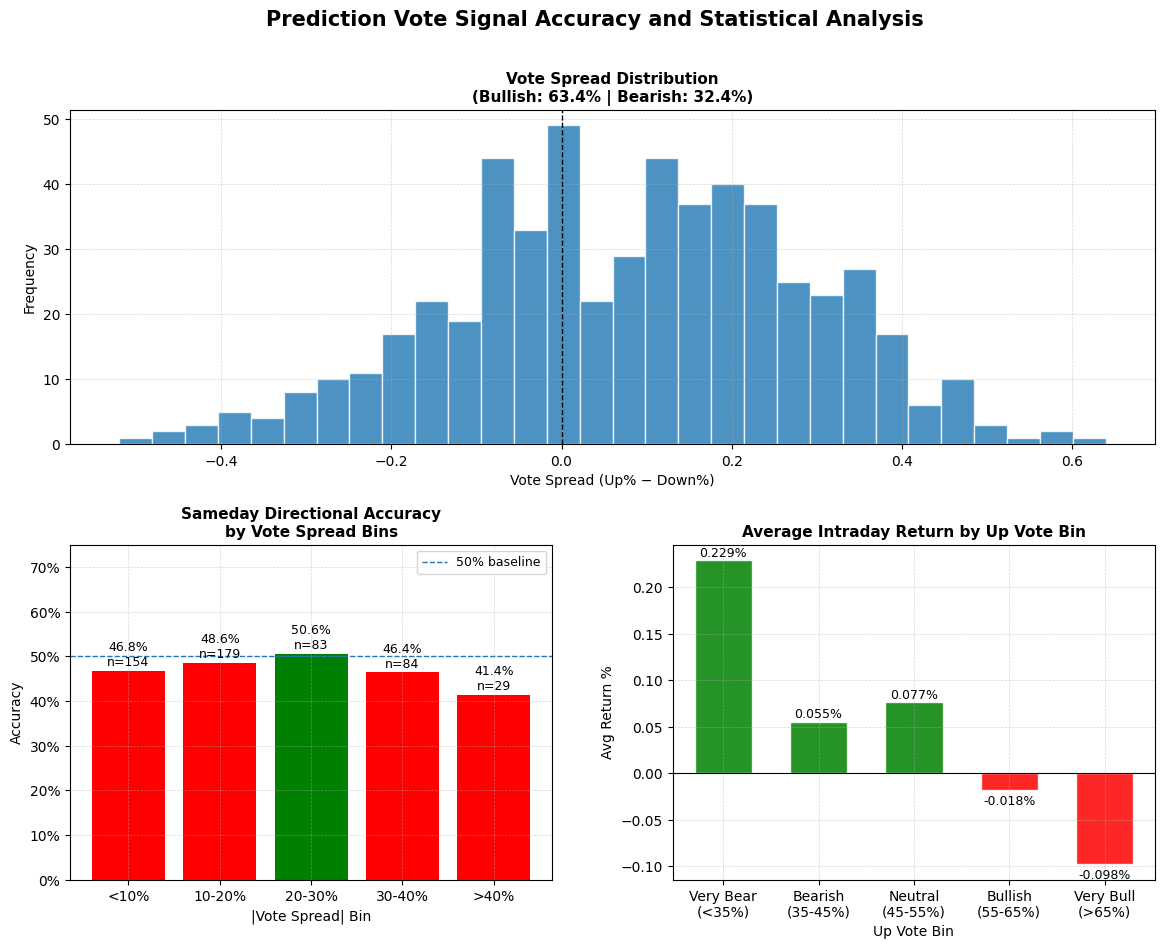

In [9]:
#Fig2: Accuracy and Distribution Analysis
fig = plt.figure(figsize=(14, 10))
gs = gridspec.GridSpec(2, 2, height_ratios=[1, 1], hspace=0.3, wspace=0.25)
ax1 = plt.subplot(gs[0, :]) 
ax2 = plt.subplot(gs[1, 0])  
ax3 = plt.subplot(gs[1, 1])  
fig.suptitle('Prediction Vote Signal Accuracy and Statistical Analysis',
             fontsize=15, fontweight='bold')

#Vote Spread Distribution
ax1.hist(df_votes['vote_spread'], bins=30, alpha=0.8, edgecolor='white')
ax1.axvline(0, lw=1, color='black', ls='--')
bull_pct = (df_votes['vote_spread'] > 0).mean()
bear_pct = (df_votes['vote_spread'] < 0).mean()
ax1.set_title(f'Vote Spread Distribution\n(Bullish: {bull_pct:.1%} | Bearish: {bear_pct:.1%})', fontsize=11, fontweight='bold')
ax1.set_xlabel('Vote Spread (Up% − Down%)')
ax1.set_ylabel('Frequency')

#Sameday Accuracy by vote spread bin
bars=ax2.bar(accuracy['vspread_bin'].astype(str),
            accuracy['Sameday_Acc'],
            color=['red' if x<0.5 else 'green' for x in accuracy['Sameday_Acc']])
ax2.axhline(0.5, lw=1, ls='--', label='50% baseline')
for bar,c,v in zip(bars, accuracy['Count'], accuracy['Sameday_Acc %']):
    ax2.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'{v}\nn={c}', ha='center', va='bottom', fontsize=9)
ax2.set_title('Sameday Directional Accuracy\nby Vote Spread Bins', fontsize=11, fontweight='bold')
ax2.set_xlabel('|Vote Spread| Bin')
ax2.set_ylabel('Accuracy')
ax2.set_ylim(0, 0.75)
ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
ax2.legend(fontsize=9)

#Avg intraday return by Up vote bin
cols = ['red' if v < 0 else 'green' for v in ret_by_bin.values]
bars = ax3.bar(ret_by_bin.index, ret_by_bin.values, color=cols, alpha=0.85, edgecolor='white', width=0.6)
ax3.axhline(0, color='black', lw=0.8)
for b, v in zip(bars, ret_by_bin.values):
    ax3.text(b.get_x()+b.get_width()/2, v+(0.001 if v>=0 else -0.004),
            f'{v:.3f}%', ha='center', va='bottom' if v>=0 else 'top', fontsize=9)
ax3.set_title('Average Intraday Return by Up Vote Bin', fontsize=11, fontweight='bold')
ax3.set_xlabel('Up Vote Bin')
ax3.set_ylabel('Avg Return %')

for x in [ax1, ax2, ax3]:
    x.grid(True, alpha=0.5, ls='--', linewidth=0.5)
plt.tight_layout()
fig.savefig('Accuracy Analysis', dpi=300, bbox_inches='tight')

In [10]:
#Up vote exceed 60%
print(f'n_days: {(df_votes['Up']>0.6).sum()}')
print(f'Market Move Down days: {(df_votes[df_votes['Up']>0.6]['intraday_return']<0).sum()}')
print(f'Market Move Down days%:{(df_votes[df_votes['Up']>0.6]['intraday_return']<0).sum()/ (df_votes['Up']>0.6).sum() *100: .1f}%')
print(f'Average Return: {(df_votes[df_votes['Up']>0.6]['intraday_return']).mean() * 100: .3f}%')

n_days: 153
Market Move Down days: 85
Market Move Down days%: 55.6%
Average Return: -0.133%


In [11]:
#Down vote exceed 60%
print(f'n_days: {(df_votes['Down']>0.6).sum()}')
print(f'Market Move Up days: {(df_votes[df_votes['Down']>0.6]['intraday_return']>0).sum()}')
print(f'Market Move Up days%:{(df_votes[df_votes['Down']>0.6]['intraday_return']>0).sum()/ (df_votes['Down']>0.6).sum() *100: .1f}%')
print(f'Average Return: {(df_votes[df_votes['Down']>0.6]['intraday_return']).mean() * 100: .3f}%')

n_days: 43
Market Move Up days: 18
Market Move Up days%: 41.9%
Average Return: -0.027%


### 3. Trading Strategy based on Social Media Sentiment

In [12]:
commission = 0.0005
initial = 100000
def backtest(df_sub, signal, strat):
    d = df_sub.copy()
    d['Signal']=signal
    d=d[d['Signal']!=0].reset_index(drop=True)
    if len(d) == 0:
        return None
    d['gross_ret']=d['intraday_return']*d['Signal']
    d['net_ret']=d['gross_ret'] - commission
    val = initial
    cur_val = []
    for r in d['net_ret']:
        val *= (1+r)
        cur_val.append(val)
    d['Value']=cur_val
    arr = np.array(cur_val)
    peak = np.maximum.accumulate(arr)
    dd = ((arr - peak)/peak)*100
    n_yrs = max((d['Date'].iloc[-1] - d['Date'].iloc[0]).days/365.25, 0.5)
    total_ret = (((d['Value'].iloc[-1]/initial)-1)*100)
    return {
        'strat':strat,
        'df':d,
        'cur_value': np.concatenate([[initial], arr]),
        'date': np.concatenate([[d['Date'].iloc[0]], d['Date'].values]),
        'n_trades': len(d),
        'win_rate': (d['net_ret']>0).mean() * 100,
        'total_ret': total_ret,
        'cagr': ((cur_val[-1]/initial)**(1/n_yrs)-1)*100,
        'sharpe_ratio': d['net_ret'].mean()/d['net_ret'].std()*np.sqrt(252),
        'max_dd': dd.min(),
        'avg_ret': d['net_ret'].mean()*100,
        'dd':dd,
        'dd_dates': d['Date'],
        'net_ret': d['net_ret'],
        'monthly': d.groupby(d['Date'].dt.to_period('M'))['net_ret'].sum()*100,
    }

In [13]:
#Trade Strategy
s1 = backtest(df_votes, np.where(df_votes['Up']>df_votes['Down'], 1, -1), 'S1.Follow Majority (Always)')
s2 = backtest(df_votes, np.where(df_votes['vote_spread']>0.15, 1,
                                 np.where(df_votes['vote_spread']<-0.15, -1, 0)), 'S2.Follow Majority (High Conviction, |Vote Spread|>15%)')
s3 = backtest(df_votes, np.where(df_votes['Up']>df_votes['Down'], -1, 1), 'S3.Contrarian (Always)')
s4 = backtest(df_votes, np.where(df_votes['Up']>0.6,-1,
                                  np.where(df_votes['Down']>0.6, 1, 0)), 'S4.Extreme Contrarian (Up/Down>0.6)')
result = [r for r in [s1, s2, s3, s4] if r]

In [14]:
#Buy and Hold benchmark
bh_ret = df['Close'].pct_change().dropna()
bh_val = np.cumprod(1+bh_ret.values)*initial
bh_total = (bh_val[-1]/initial -1)*100
bh_date = df['Date'].iloc[1:].values
bh_n_yrs = (df['Date'].iloc[-1]-df['Date'].iloc[0]).days/365.25
bh_cagr = ((bh_val[-1]/initial)**(1/bh_n_yrs)-1)*100
bh_sharpe = bh_ret.mean()/bh_ret.std()*np.sqrt(252)

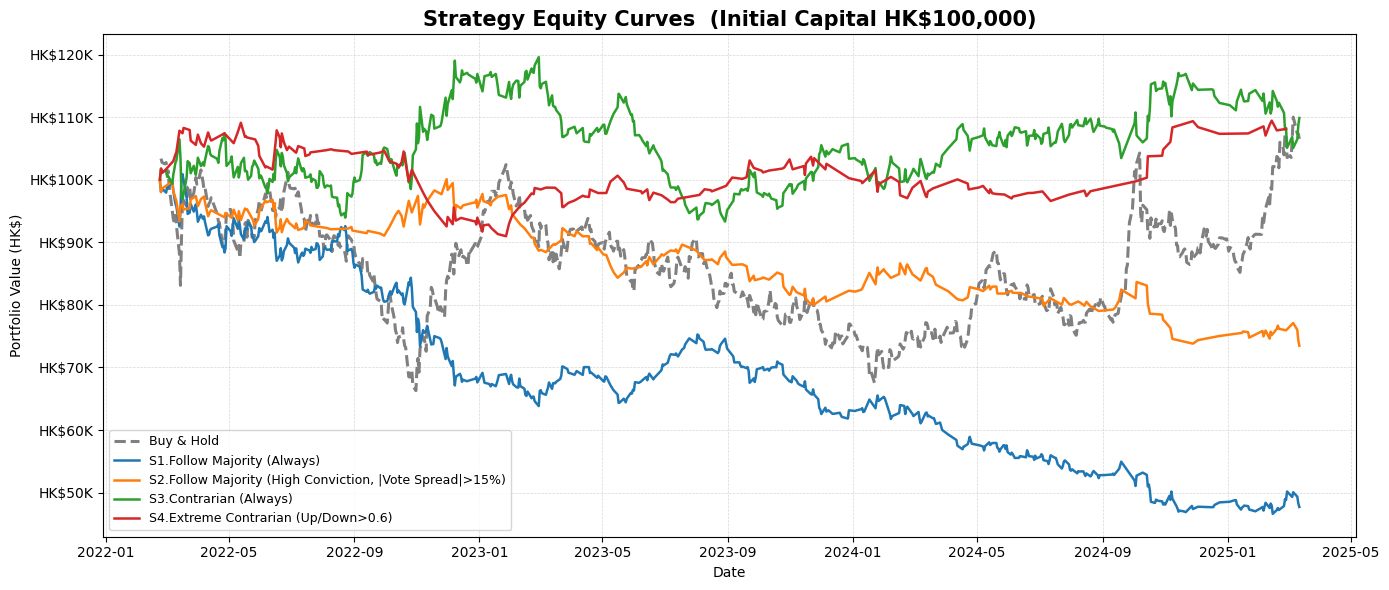

In [15]:
#Fig3: Equity Curves
fig, ax = plt.subplots(figsize=(14, 6))
ax.plot(bh_date, bh_val, color='gray', lw=2.2, linestyle='--', label='Buy & Hold', zorder=2)
for i, r in enumerate(result):
    ax.plot(pd.to_datetime(r['date']), r['cur_value'], lw=1.8, label=r['strat'], zorder=3)
ax.set_title('Strategy Equity Curves  (Initial Capital HK$100,000)', fontsize=15, fontweight='bold')
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (HK$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'HK${x/1000:.0f}K'))
ax.legend(fontsize=9, loc='lower left')
ax.grid(True, alpha=0.5, ls='--', linewidth=0.5)
plt.tight_layout()
fig.savefig('Equity Curves', dpi=300, bbox_inches='tight')

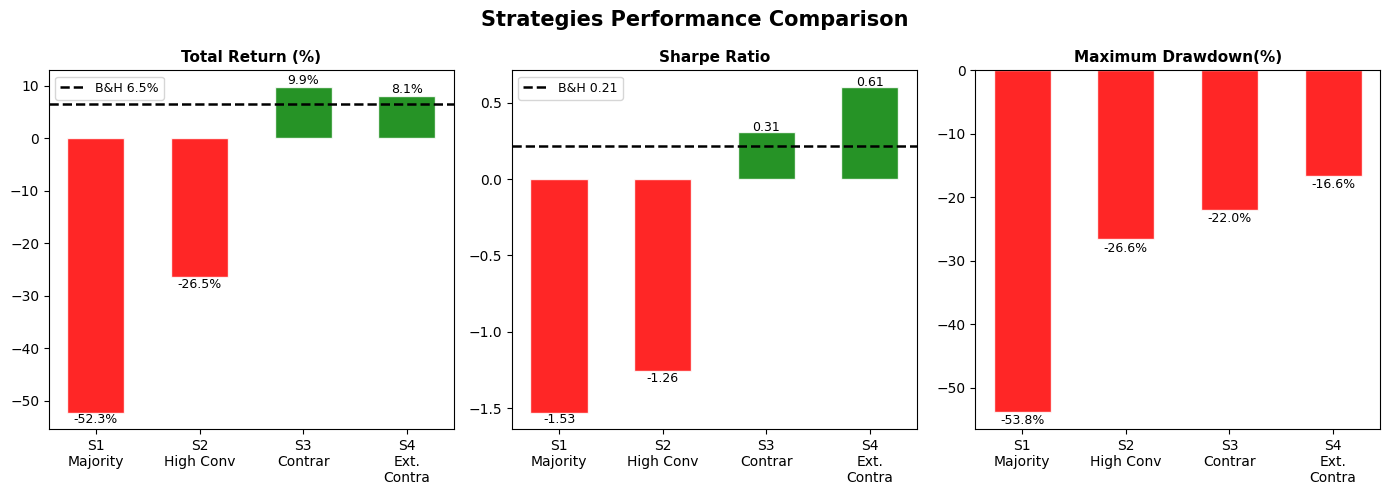

In [16]:
#Fig4: Strategies Performance Comparison
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle('Strategies Performance Comparison', fontsize=15, fontweight='bold')
short_names = ['S1\nMajority','S2\nHigh Conv','S3\nContrar','S4\nExt.\nContra']

#Total return
ax = axes[0]
rets = [r['total_ret'] for r in result]
bars = ax.bar(short_names, rets,
              color=['green' if v>=0 else 'red' for v in rets],
              alpha=0.85, edgecolor='white', width=0.55)
ax.axhline(bh_total, color='black', ls='--', lw=1.8, label=f'B&H {bh_total:.1f}%')
for b, v in zip(bars, rets):
    ax.text(b.get_x()+b.get_width()/2, v+(0.5 if v>=0 else -2), f'{v:.1f}%',
            ha='center', fontsize=9)
ax.set_title('Total Return (%)',fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

#Sharp Ratio
ax = axes[1]
sharpe = [r['sharpe_ratio'] for r in result]
bars = ax.bar(short_names, sharpe,
              color=['green' if v>=0 else 'red' for v in rets],
              alpha=0.85, edgecolor='white', width=0.55)
ax.axhline(bh_sharpe, color='black', ls='--', lw=1.8, label=f'B&H {bh_sharpe:.2f}')
for b, v in zip(bars, sharpe):
    ax.text(b.get_x()+b.get_width()/2, v+(0.005 if v>=0 else -0.07), f'{v:.2f}',
            ha='center', fontsize=9)
ax.set_title('Sharpe Ratio',fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

#Max Drawdown
ax = axes[2]
max_dd = [r['max_dd'] for r in result]
bars = ax.bar(short_names, max_dd,
              color='red',
              alpha=0.85, edgecolor='white', width=0.55)
for b, v in zip(bars, max_dd):
    ax.text(b.get_x()+b.get_width()/2, v-2, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Maximum Drawdown(%)',fontsize=11, fontweight='bold')

plt.tight_layout()
fig.savefig('Strategies Performance Comparison', dpi=300, bbox_inches='tight')

In [17]:
summary = {
    'n_days':len(df),
    'n_voted':len(df_votes),
    'coverage':round((len(df_votes) / len(df) * 100), 1),
    'accuracy':sameday_acc,
    'up_mean':round(df_votes['Up'].mean()*100, 1),
    'down_mean':round(df_votes['Down'].mean()*100, 1),
    'bull_days':int(df_votes['bull_day'].sum()),
    'bear_days':int((df_votes['bull_day']==0).sum()),
    'bh_total':round(bh_total, 1),
    'bh_cagr':round(bh_cagr, 1),
    'bh_sharpe':round(bh_sharpe, 2),
    'date_start':str(df['Date'].min().date()),
    'date_end':str(df['Date'].max().date()),
    'results': [{
        'strat':r['strat'],
        'trades':r['n_trades'],
        'win_rate':round(r['win_rate'], 1),
        'total_ret': round(r['total_ret'], 1),
        'cagr':round(r['cagr'], 1),
        'sharpe':round(r['sharpe_ratio'], 2),
        'max_dd':round(r['max_dd'], 1),
        'avg_ret':round(r['avg_ret'], 4),
    } for r in result],
}
with open('summary.json', 'w') as f:
    json.dump(summary, f, indent=2)

print("BACKTEST RESULTS")
print(f"Data: {summary['date_start']} to {summary['date_end']}  | Trading days: {summary['n_days']}  | Vote coverage: {summary['coverage']}%")
print(f"Overall directional accuracy: {summary['accuracy']*100:.1f}%")
print(f"B&H: Total {bh_total:.1f}%  CAGR {bh_cagr:.1f}%  Sharpe {bh_sharpe:.2f}")
print()
for r in result:
    print(f"{r['strat']}")
    print(f"  Trades:{r['n_trades']:4d}  WinRate:{r['win_rate']:.1f}%  Return:{r['total_ret']:+.1f}%  CAGR:{r['cagr']:+.1f}%  Sharpe:{r['sharpe_ratio']:.2f}  MaxDD:{r['max_dd']:.1f}%")


BACKTEST RESULTS
Data: 2022-02-23 to 2025-03-12  | Trading days: 747  | Vote coverage: 73.9%
Overall directional accuracy: 47.8%
B&H: Total 6.5%  CAGR 2.1%  Sharpe 0.21

S1.Follow Majority (Always)
  Trades: 552  WinRate:47.1%  Return:-52.3%  CAGR:-21.6%  Sharpe:-1.53  MaxDD:-53.8%
S2.Follow Majority (High Conviction, |Vote Spread|>15%)
  Trades: 278  WinRate:46.8%  Return:-26.5%  CAGR:-9.6%  Sharpe:-1.26  MaxDD:-26.6%
S3.Contrarian (Always)
  Trades: 552  WinRate:50.7%  Return:+9.9%  CAGR:+3.1%  Sharpe:0.31  MaxDD:-22.0%
S4.Extreme Contrarian (Up/Down>0.6)
  Trades: 196  WinRate:51.5%  Return:+8.1%  CAGR:+2.6%  Sharpe:0.61  MaxDD:-16.6%


### 4. Technical Indicator Filters

In [18]:
#Technical indicator calculations
#SMA20
df_votes['SMA20']=df_votes['Close'].rolling(20).mean()

#RSI
def calc_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(com=period-1, min_periods=period).mean()
    avg_loss = loss.ewm(com=period-1, min_periods=period).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return 100 - (100 / (1 + rs))
df_votes['RSI14'] = calc_rsi(df_votes['Close'])

# MACD (12/26/9)
ema12 = df_votes['Close'].ewm(span=12, adjust=False).mean()
ema26 = df_votes['Close'].ewm(span=26, adjust=False).mean()
df_votes['MACD'] = ema12 - ema26
df_votes['MACD_signal'] = df_votes['MACD'].ewm(span=9, adjust=False).mean()
df_votes['MACD_hist'] = df_votes['MACD'] - df_votes['MACD_signal']

In [19]:
#Indicator Filter
#SMA: +1 if Close>SMA20 (bullish trend), -1 if Close<SMA20 (bearish trend)
df_votes['flt_sma'] = np.where(df_votes['Close']>df_votes['SMA20'], 1, -1)

#RSI: +1 oversold (<40), -1 overbought(>60), 0 neutral
df_votes['flt_rsi'] = np.where(df_votes['RSI14']<40, 1,
                               np.where(df_votes['RSI14']>60, -1, 0))

#MACD: +1 if MACD>signal (bullish monmentum), -1 if MACD<signal (bearish momentum)
df_votes['flt_macd'] = np.where(df_votes['MACD']>df_votes['MACD_signal'], 1, -1)

#Combined 3
score = df_votes['flt_sma'] + df_votes['flt_rsi'] + df_votes['flt_macd']
df_votes['flt_all'] = np.sign(score)

df_votes[['Date','Close','SMA20','RSI14','MACD',
          'MACD_signal','flt_sma','flt_rsi','flt_macd','flt_all']].tail(10)

,Date,Close,SMA20,RSI14,MACD,MACD_signal,flt_sma,flt_rsi,flt_macd,flt_all
732,2025-02-20,22576.98,20776.3065,70.511280,781.229416,528.727057,1,-1,1,1
735,2025-02-25,23034.02,20965.9630,73.581198,823.342522,587.650150,1,-1,1,1
736,2025-02-26,23787.93,21202.1450,77.704445,907.095269,651.539174,1,-1,1,1
737,2025-02-27,23718.29,21427.0705,76.516476,956.820922,712.595523,1,-1,1,1
738,2025-02-28,22941.32,21609.8330,64.642238,922.895312,754.655481,1,-1,1,1
741,2025-03-05,23594.21,21813.3990,68.996213,937.880486,791.300482,1,-1,1,1
742,2025-03-06,24369.71,22052.6815,73.215267,1000.796158,833.199617,1,-1,1,1
744,2025-03-10,23783.49,22236.5285,65.913346,991.919990,864.943692,1,-1,1,1
745,2025-03-11,23782.14,22436.6970,65.897047,973.554104,886.665774,1,-1,1,1
746,2025-03-12,23600.31,22605.4570,63.615318,933.565286,896.045676,1,-1,1,1


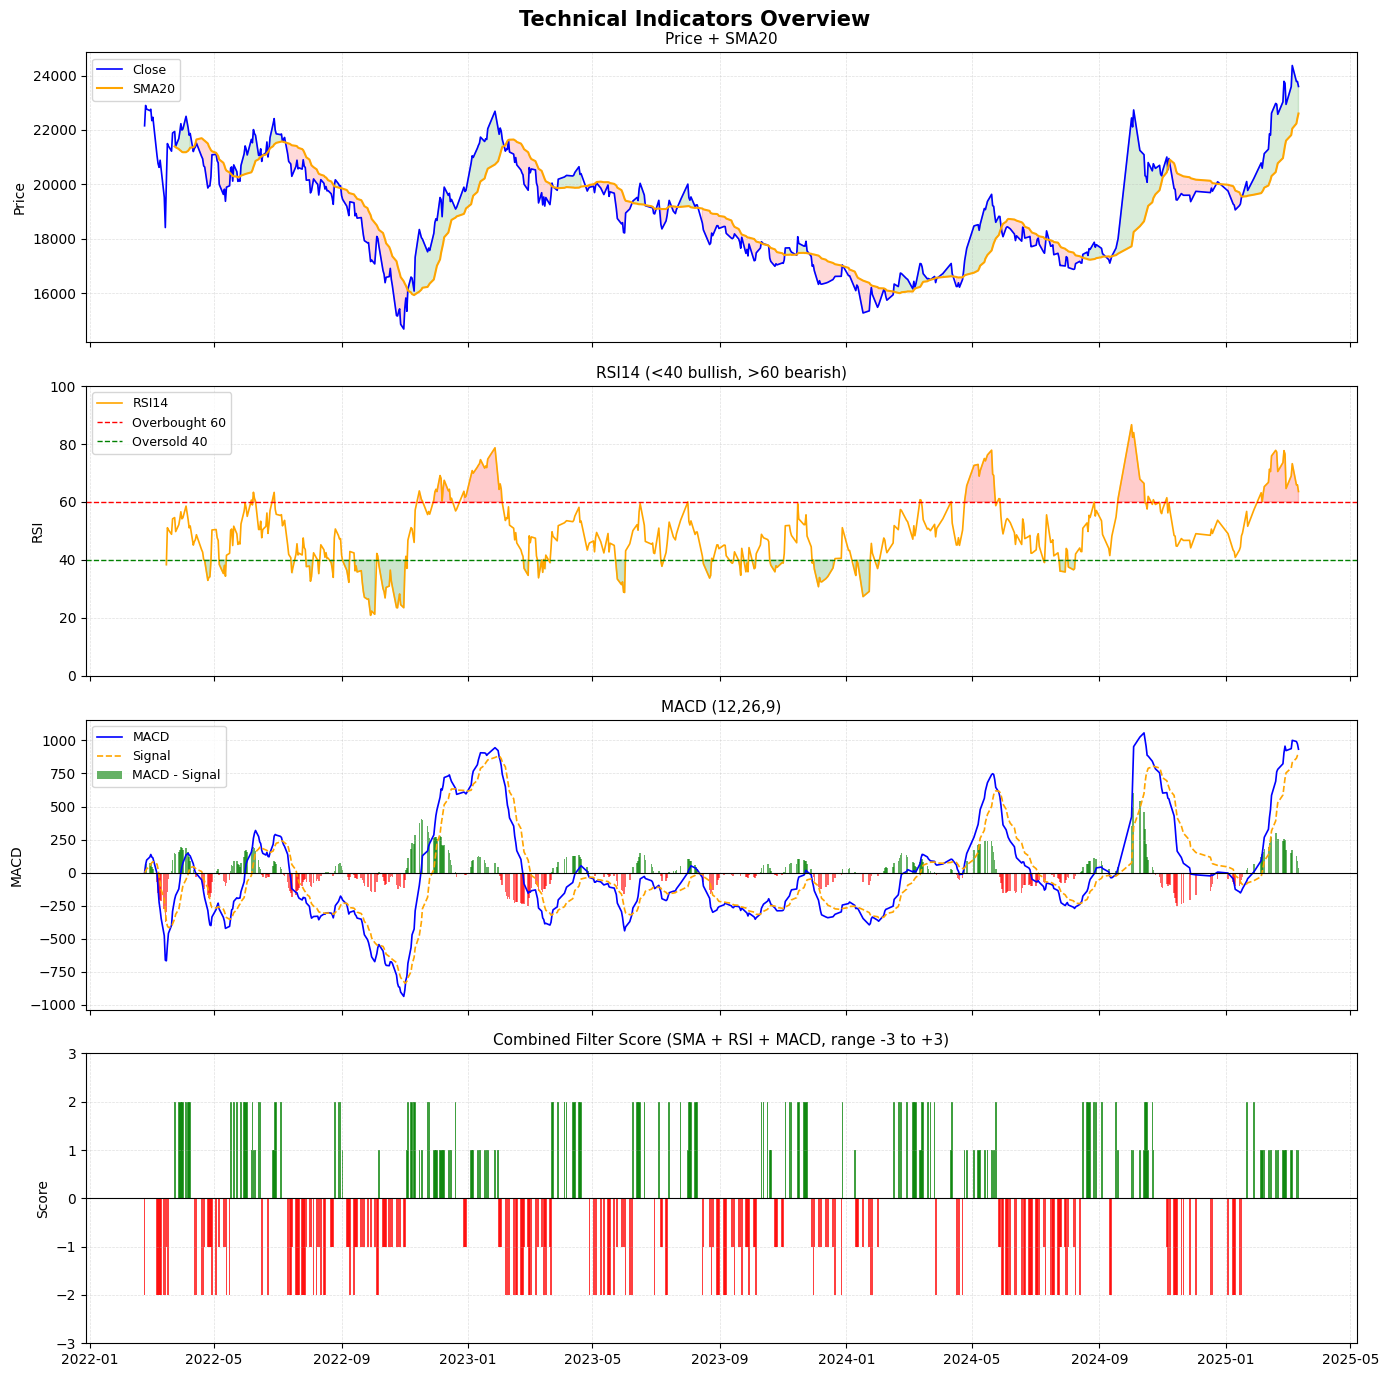

In [20]:
#Fig5: Technical Indicators Overview
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
fig.suptitle('Technical Indicators Overview', fontsize=15, fontweight='bold')

#SMA
ax = axes[0]
ax.plot(df_votes['Date'], df_votes['Close'], lw=1.2, label='Close', color='blue')
ax.plot(df_votes['Date'], df_votes['SMA20'], lw=1.5, label='SMA20', color='orange')
ax.fill_between(df_votes['Date'], df_votes['Close'], df_votes['SMA20'],
                where=(df_votes['Close'] >= df_votes['SMA20']), alpha=0.15, color='green')
ax.fill_between(df_votes['Date'], df_votes['Close'], df_votes['SMA20'],
                where=(df_votes['Close'] < df_votes['SMA20']), alpha=0.15, color='red')
ax.set_ylabel('Price', fontsize=10)
ax.set_title('Price + SMA20', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, ls='--', lw=0.5)

#RSI
ax = axes[1]
ax.plot(df_votes['Date'], df_votes['RSI14'], lw=1.2, color='orange', label='RSI14')
ax.axhline(60, color='red', ls='--', lw=1, label='Overbought 60')
ax.axhline(40, color='green', ls='--', lw=1, label='Oversold 40')
ax.fill_between(df_votes['Date'], df_votes['RSI14'], 60,
                where=(df_votes['RSI14'] >= 60), alpha=0.2, color='red')
ax.fill_between(df_votes['Date'], df_votes['RSI14'], 40,
                where=(df_votes['RSI14'] <= 40), alpha=0.2, color='green')
ax.set_ylim(0, 100)
ax.set_ylabel('RSI', fontsize=10)
ax.set_title('RSI14 (<40 bullish, >60 bearish)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, ls='--', lw=0.5)

# MACD
ax = axes[2]
ax.plot(df_votes['Date'], df_votes['MACD'], lw=1.2, label='MACD', color='blue')
ax.plot(df_votes['Date'], df_votes['MACD_signal'], lw=1.2, label='Signal', color='orange', ls='--')
hist_colors = ['green' if v >= 0 else 'red' for v in df_votes['MACD_hist']]
ax.bar(df_votes['Date'], df_votes['MACD_hist'], color=hist_colors, alpha=0.6, width=1.5, label='MACD - Signal')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('MACD', fontsize=10)
ax.set_title('MACD (12,26,9)', fontsize=11)
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.4, ls='--', lw=0.5)

# Combined score
ax = axes[3]
bar_cols = ['green' if v > 0 else ('red' if v < 0 else 'gray') for v in score]
ax.bar(df_votes['Date'], score, color=bar_cols, alpha=0.75, width=1.5)
ax.axhline(0, color='black', lw=0.8)
ax.set_yticks([-3,-2,-1,0,1,2,3])
ax.set_ylabel('Score', fontsize=10)
ax.set_title('Combined Filter Score (SMA + RSI + MACD, range -3 to +3)', fontsize=11)
ax.grid(True, alpha=0.4, ls='--', lw=0.5)

plt.tight_layout()
fig.savefig('Technical Indicators Overview', dpi=300, bbox_inches='tight')

In [21]:
#Filter Strategy Backtest
def apply_filter(base_sig, flt_val, mode):
    sig = base_sig.copy().astype(float)
    flt = np.array(flt_val)
    if mode == 'agree':
        sig[sig*flt <=0] = 0   #trade only when filter sign == signal sign
    else: #nonoppose
        sig[sig * flt < 0] = 0    #trade unless filter opposes signal
    return sig

#Base sig S3 contra and S4 extre contra
sig_contra = np.where(df_votes['Up']>df_votes['Down'], -1, 1).astype(float)
sig_ext_contra = np.where(df_votes['Up']>0.6, -1, 
                          np.where(df_votes['Down']>0.6, 1, 0)).astype(float)

#Filter signal
filtered_strategies = {
    'S3.Contrarian + SMA': apply_filter(sig_contra, df_votes['flt_sma'],'agree'),
    'S3.Contrarian + RSI': apply_filter(sig_contra, df_votes['flt_rsi'],'nonoppose'),
    'S3.Contrarian + MACD': apply_filter(sig_contra, df_votes['flt_macd'],'agree'),
    'S3.Contrarian + All Filters': apply_filter(sig_contra, df_votes['flt_all'],'agree'),
    'S4.Ext.Contra + SMA': apply_filter(sig_ext_contra,df_votes['flt_sma'],'agree'),
    'S4.Ext.Contra + RSI': apply_filter(sig_ext_contra, df_votes['flt_rsi'],'nonoppose'),
    'S4.Ext.Contra + MACD': apply_filter(sig_ext_contra, df_votes['flt_macd'],'agree'),
    'S4.Ext.Contra + All Filters': apply_filter(sig_ext_contra, df_votes['flt_all'],'agree'),
}

filtered_results = []
for name, sig in filtered_strategies.items():
    r = backtest(df_votes, sig, name)
    if r:
        filtered_results.append(r)

# Print summary
print(f"{'Strategy':<40} {'Trades':>6} {'WinRate':>8} {'CAGR':>7} {'Return':>8} {'Sharpe':>7} {'MaxDD':>7}")
for r in filtered_results:
    print(f"{r['strat']:<40} {r['n_trades']:>6} {r['win_rate']:>7.1f}% {r['cagr']:>+7.1f}% {r['total_ret']:>+7.1f}% {r['sharpe_ratio']:>7.2f} {r['max_dd']:>6.1f}%")

Strategy                                 Trades  WinRate    CAGR   Return  Sharpe   MaxDD
S3.Contrarian + SMA                         229    59.8%   +27.5%  +109.4%    3.76  -10.5%
S3.Contrarian + RSI                         491    48.5%   -10.6%   -29.0%   -0.82  -38.2%
S3.Contrarian + MACD                        246    54.9%   +18.6%   +68.1%    2.47  -10.7%
S3.Contrarian + All Filters                 208    57.7%   +22.2%   +82.8%    3.31  -10.9%
S4.Ext.Contra + SMA                          70    64.3%   +10.4%   +31.6%    5.64   -3.4%
S4.Ext.Contra + RSI                         187    49.7%    +0.7%    +2.3%    0.25  -18.1%
S4.Ext.Contra + MACD                         76    56.6%    +6.2%   +18.4%    3.21   -5.3%
S4.Ext.Contra + All Filters                  65    61.5%    +8.8%   +25.9%    5.13   -4.0%


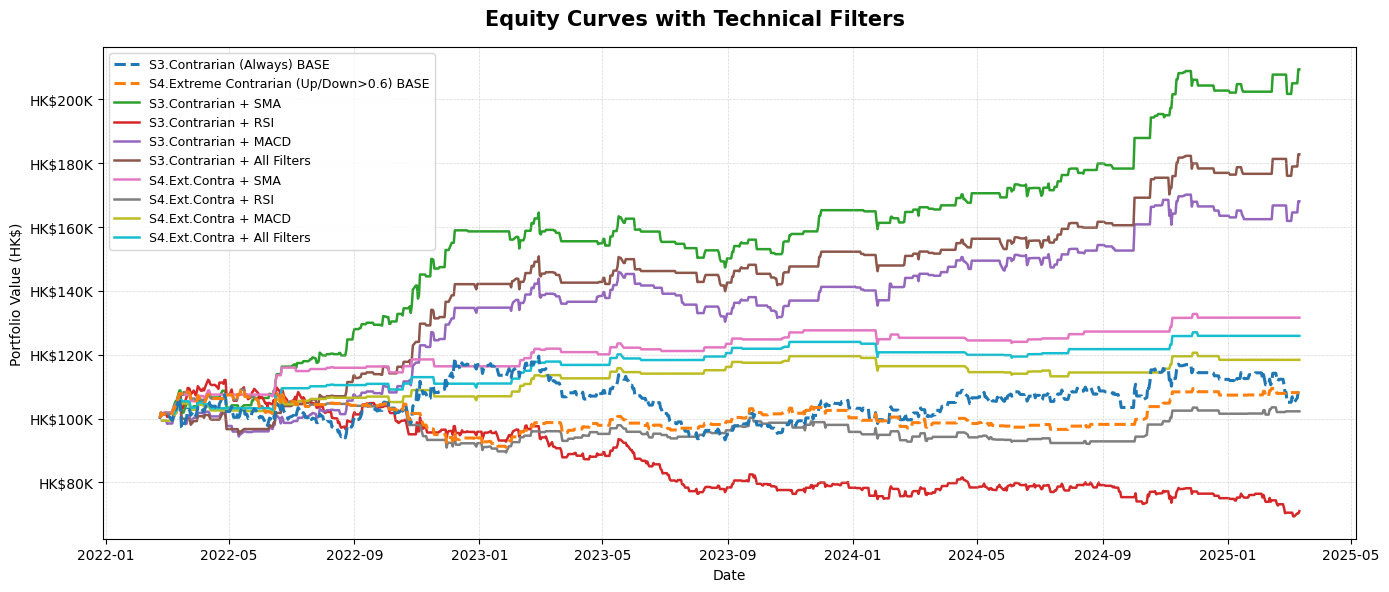

In [22]:
#Fig6: Equity Curves with Technical Filter
full_idx = pd.date_range(df_votes['Date'].min(), df_votes['Date'].max(), freq='B')
fig, ax = plt.subplots(figsize=(14, 6))
fig.suptitle('Equity Curves with Technical Filters', fontsize=15, fontweight='bold')
for i, r in enumerate(result[2:]):
    eq = pd.Series(r['cur_value'][1:], index=pd.to_datetime(r['date'][1:]))
    eq = eq.reindex(full_idx).ffill()
    ax.plot(full_idx, eq, lw=2.2, ls='--', label=f'{r['strat']} BASE', zorder=2)
for i, r in enumerate(filtered_results):
    eq = pd.Series(r['cur_value'][1:], index=pd.to_datetime(r['date'][1:]))
    eq = eq.reindex(full_idx).ffill()
    ax.plot(full_idx, eq, lw=1.8, label=r['strat'], zorder=1)
ax.set_xlabel('Date')
ax.set_ylabel('Portfolio Value (HK$)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'HK${x/1000:.0f}K'))
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.5, ls='--', linewidth=0.5)
plt.tight_layout()
fig.savefig('Equity Curves with Technical Filter', dpi=300, bbox_inches='tight')

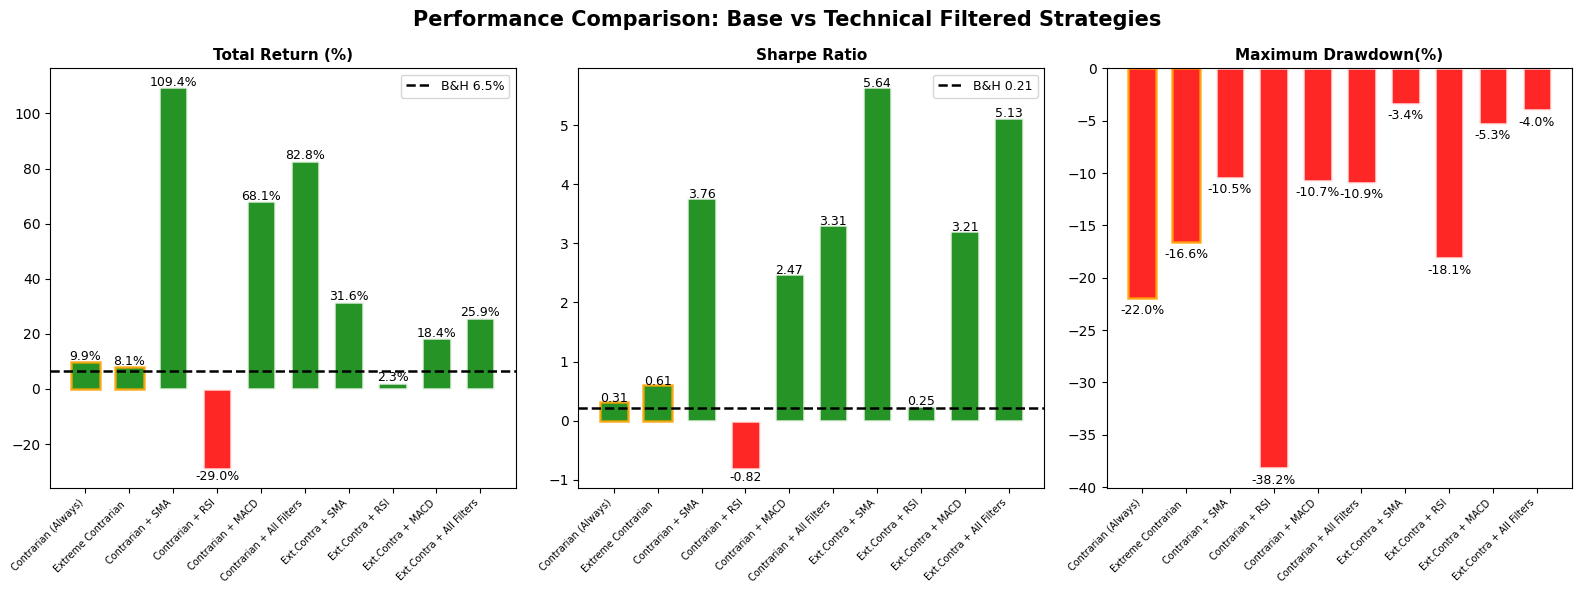

In [23]:
#Fig7: Performance Comparison (with Technical Filter)
all_results = result[2:] + filtered_results
names = [r['strat'].replace('S1.','').replace('S2.','').replace('S3.','').
    replace('S4.','').replace('(Up/Down>0.6)','') for r in all_results]
edge = ['orange' if i < 2 else 'white' for i in range(len(all_results))]
fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Performance Comparison: Base vs Technical Filtered Strategies',
             fontsize=15, fontweight='bold')
#Total return
ax = axes[0]
rets = [r['total_ret'] for r in all_results]
bars = ax.bar(names, rets,
              color=['green' if v>=0 else 'red' for v in rets],
              alpha=0.85, edgecolor=edge, linewidth=1.8, width=0.65)
ax.axhline(bh_total, color='black', ls='--', lw=1.8, label=f'B&H {bh_total:.1f}%')
for b, v in zip(bars, rets):
    ax.text(b.get_x()+b.get_width()/2, v+(0.5 if v>=0 else -4), f'{v:.1f}%',
            ha='center', fontsize=9)
ax.set_title('Total Return (%)',fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

#Sharp Ratio
ax = axes[1]
sharpe = [r['sharpe_ratio'] for r in all_results]
bars = ax.bar(names, sharpe,
              color=['green' if v>=0 else 'red' for v in rets],
              alpha=0.85, edgecolor=edge, linewidth=1.8, width=0.65)
ax.axhline(bh_sharpe, color='black', ls='--', lw=1.8, label=f'B&H {bh_sharpe:.2f}')
for b, v in zip(bars, sharpe):
    ax.text(b.get_x()+b.get_width()/2, v+(0.005 if v>=0 else -0.2), f'{v:.2f}',
            ha='center', fontsize=9)
ax.set_title('Sharpe Ratio',fontsize=11, fontweight='bold')
ax.legend(fontsize=9)

#Max Drawdown
ax = axes[2]
max_dd = [r['max_dd'] for r in all_results]
bars = ax.bar(names, max_dd,
              color='red',
              alpha=0.85, edgecolor=edge, linewidth=1.8, width=0.65)
for b, v in zip(bars, max_dd):
    ax.text(b.get_x()+b.get_width()/2, v-1.5, f'{v:.1f}%', ha='center', fontsize=9)
ax.set_title('Maximum Drawdown(%)',fontsize=11, fontweight='bold')

for ax in axes:
    ax.set_xticks(range(len(names))) 
    ax.set_xticklabels(names, rotation=45, ha='right', fontsize=7)
plt.tight_layout()
fig.savefig('Strategies Performance Comparison (with Technical Filter)', dpi=300, bbox_inches='tight')